# IND320 Project work 1

**Autor:** Inge Gilje Gunnarshaug

## 1. Introduction

This is the notebook for the first task in IND320. The corresponding streamlit app and github repository can be found here:

### Project links

- **GitHub repository:** https://github.com/IngeGiljeGunnarshaug/ind320-inge-gilje-gunnarshaug
- **Streamlit app:** https://ind320-inge-gilje-gunnarshaug.streamlit.app/

## 2. Environment and Imports

This notebook uses Pandas for data processing and Matplotlib for plotting.
The CSV file is stored at `data/reservoirs.csv`, relative to this notebook.

The required packages and tested versions are documented in the repository.

In [26]:
# Display Matplotlib figures directly inside the notebook.
%matplotlib inline

In [27]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Path relative to the notebook's working directory.
DATA_PATH = Path("data") / "reservoirs.csv"

# Show the working directory to help diagnose file-path problems.
print("Working directory:", Path.cwd())

if not DATA_PATH.is_file():
    raise FileNotFoundError(f"CSV file not found: {DATA_PATH.resolve()}")

Working directory: /Users/ingegunnarshaug/Skole/H2026/ind320/ind320-inge-gilje-gunnarshaug


## 3. Load and Inspect the Data

### 3.1 Load data

In [6]:
# Preserve the imported data so preparation can be compared with the source.
raw_df = pd.read_csv(DATA_PATH)

print(f"Loaded {raw_df.shape[0]:,} rows and {raw_df.shape[1]} columns.")

Loaded 14,877 rows and 11 columns.


### 3.2 Preview and sizes

In [7]:
# These previews show the original file order, before chronological sorting.
print("First five rows:")
display(raw_df.head())

print("Last five rows:")
display(raw_df.tail())

print("Dataset dimensions (rows, columns):", raw_df.shape)

First five rows:


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


Last five rows:


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
14872,2026-07-19,VASS,3,2026,29,0.796849,28.155403,22.435612,2026-07-29T13:00:00,0.794957,0.001892
14873,2026-09-06,VASS,3,2026,36,0.826252,28.155403,23.263466,2026-09-16T13:00:00,0.827641,-0.001389
14874,2026-08-30,VASS,3,2026,35,0.827718,28.155403,23.304743,2026-09-09T13:00:00,0.829898,-0.002180
14875,2026-09-06,VASS,1,2026,36,0.570397,36.044464,20.559645,2026-09-16T13:00:00,0.567087,0.003310
14876,2026-09-06,VASS,2,2026,36,0.516978,23.237715,12.013381,2026-09-16T13:00:00,0.514423,0.002555


Dataset dimensions (rows, columns): (14877, 11)


11 columns with norwegian headers, with different datatype; some numerical, some categorical and some dates. Seems like 0001-01-01T00:00:00 is a placeholder for missing neste_Publiseringsdato. It is also worth notecing that the rows are not sorted by date.

### 3.3 datatypes and summaries

In [8]:
# Inspect inferred types and the number of nonmissing values.
raw_df.info()

# Numeric summaries include identifiers, so interpret them accordingly.
print("\nNumeric summary statistics:")
display(raw_df.describe().T)

# Inspect text columns separately.
print("Text-column summary:")
display(raw_df.describe(include=["object", "string"]).T)

<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   dato_Id                   14877 non-null  str    
 1   omrType                   14877 non-null  str    
 2   omrnr                     14877 non-null  int64  
 3   iso_aar                   14877 non-null  int64  
 4   iso_uke                   14877 non-null  int64  
 5   fyllingsgrad              14877 non-null  float64
 6   kapasitet_TWh             14877 non-null  float64
 7   fylling_TWh               14877 non-null  float64
 8   neste_Publiseringsdato    14877 non-null  str    
 9   fyllingsgrad_forrige_uke  14877 non-null  float64
 10  endring_fyllingsgrad      14877 non-null  float64
dtypes: float64(5), int64(3), str(3)
memory usage: 1.7 MB

Numeric summary statistics:


,count,mean,std,min,25%,50%,75%,max
omrnr,14877.0,2.333333,1.490762,0.000000,1.000000,2.000000,3.000000,5.000000
iso_aar,14877.0,2010.346038,9.146696,1995.000000,2002.000000,2010.000000,2018.000000,2026.000000
iso_uke,14877.0,26.405929,15.017910,1.000000,13.000000,26.000000,39.000000,53.000000
fyllingsgrad,14877.0,0.618852,0.214850,0.055160,0.456234,0.648049,0.802135,1.020072
kapasitet_TWh,14877.0,29.145860,22.739070,6.003264,17.390587,23.237715,34.043590,87.437580
fylling_TWh,14877.0,18.139713,15.966211,0.331142,7.321973,14.501389,22.203530,84.544820
fyllingsgrad_forrige_uke,14877.0,0.618890,0.214843,0.055160,0.456356,0.648114,0.802133,1.020037
endring_fyllingsgrad,14877.0,-0.000038,0.031385,-0.242484,-0.022395,-0.007072,0.016277,0.336623


Text-column summary:


,count,unique,top,freq
dato_Id,14877,1653,1995-09-03,9
omrType,14877,3,EL,8265
neste_Publiseringsdato,14877,396,0001-01-01T00:00:00,11322


The numerical columns seems to have different scales, varying from (-0.25, 0.33) to (0.3, 85). \
neste_Publiseringsdate has 11322 observations with value 0001-01-01T00:00:00.

### 3.4 Missing values, duplicates and area identifiers

In [16]:
# Blank CSV fields may become missing values; placeholder strings do not.
missing_summary = pd.DataFrame({
    "missing_count": raw_df.isna().sum(),
    "missing_percent": raw_df.isna().mean() * 100,
})

print("Missing values before preparation:")
display(missing_summary)

# Repeated dates across different areas are expected.
# A duplicate observation has the same date AND both area identifiers.
raw_key = ["dato_Id", "omrType", "omrnr"]

print("Fully duplicated rows:", raw_df.duplicated().sum())
print("Duplicated observation keys:", raw_df.duplicated(subset=raw_key).sum())

# Area numbers must be interpreted together with their area type.
area_summary = (
    raw_df.groupby(["omrType", "omrnr"])
    .size()
    .reset_index(name="observation_count")
    .sort_values(["omrType", "omrnr"])
)

print("\nAvailable areas:")
display(area_summary)

Missing values before preparation:


,missing_count,missing_percent
dato_Id,0,0.0
omrType,0,0.0
omrnr,0,0.0
iso_aar,0,0.0
iso_uke,0,0.0
fyllingsgrad,0,0.0
kapasitet_TWh,0,0.0
fylling_TWh,0,0.0
neste_Publiseringsdato,0,0.0
fyllingsgrad_forrige_uke,0,0.0


Fully duplicated rows: 0
Duplicated observation keys: 0

Available areas:


,omrType,omrnr,observation_count
0,EL,1,1653
1,EL,2,1653
2,EL,3,1653
3,EL,4,1653
4,EL,5,1653
5,NO,0,1653
6,VASS,1,1653
7,VASS,2,1653
8,VASS,3,1653


No missing values before any preperations. Also no duplicates found. \
All the area identifiers have exactly the same number of observations.

## 4. Column Definitions and Data Preparation

### 4.1 Rename columns


In [17]:
# Use descriptive names and retain units in the energy-column names.
column_mapping = {
    "dato_Id": "date",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "iso_year",
    "iso_uke": "iso_week",
    "fyllingsgrad": "fill_fraction",
    "kapasitet_TWh": "capacity_twh",
    "fylling_TWh": "stored_energy_twh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "previous_week_fill_fraction",
    "endring_fyllingsgrad": "fill_fraction_change",
}

# Work on a separate DataFrame, keeping raw_df unchanged.
df = raw_df.rename(columns=column_mapping).copy()

display(pd.DataFrame({
    "original_name": list(column_mapping.keys()),
    "english_name": list(column_mapping.values()),
}))

,original_name,english_name
0,dato_Id,date
1,omrType,area_type
2,omrnr,area_number
3,iso_aar,iso_year
4,iso_uke,iso_week
5,fyllingsgrad,fill_fraction
6,kapasitet_TWh,capacity_twh
7,fylling_TWh,stored_energy_twh
8,neste_Publiseringsdato,next_publication_date
9,fyllingsgrad_forrige_uke,previous_week_fill_fraction


### 4.2 Parse dates, and handle placeholder

In [18]:
# Observation dates are essential: stop if a value cannot be parsed.
df["date"] = pd.to_datetime(
    df["date"],
    format="%Y-%m-%d",
    errors="raise",
)

# Treat the year-0001 publication timestamp as an unavailable-date placeholder.
# This is an explicit preparation assumption, not a missing observation date.
publication_text = df["next_publication_date"].astype("string")
placeholder_mask = publication_text.eq("0001-01-01T00:00:00").fillna(False)

df["next_publication_date"] = pd.to_datetime(
    publication_text.mask(placeholder_mask),
    format="%Y-%m-%dT%H:%M:%S",
    errors="raise",
)

print(f"Publication-date placeholders replaced: {placeholder_mask.sum():,}")
print("Observation period:",
    df["date"].min().date(),
    "to",
    df["date"].max().date(),
)

Publication-date placeholders replaced: 11,322
Observation period: 1995-01-08 to 2026-09-06


### 4.3 Sort rows by date.

In [19]:
# Group each area's observations together and order them by date.
df = (
    df.sort_values(["area_type", "area_number", "date"])
    .reset_index(drop=True)
)

display(df.head())

,date,area_type,area_number,iso_year,iso_week,fill_fraction,capacity_twh,stored_energy_twh,next_publication_date,previous_week_fill_fraction,fill_fraction_change
0,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,NaT,0.734888,-0.113421
1,1995-01-15,EL,1,1995,2,0.583100,6.003264,3.500502,NaT,0.621467,-0.038367
2,1995-01-22,EL,1,1995,3,0.550604,6.003264,3.305419,NaT,0.583100,-0.032496
3,1995-01-29,EL,1,1995,4,0.508440,6.003264,3.052297,NaT,0.550604,-0.042164
4,1995-02-05,EL,1,1995,5,0.469223,6.003264,2.816870,NaT,0.508440,-0.039217


### 4.4 Distinguish measurements from metadata, and apply numerical types

In [20]:
# Only these columns represent reservoir measurements.
measurement_columns = [
    "fill_fraction",
    "capacity_twh",
    "stored_energy_twh",
    "previous_week_fill_fraction",
    "fill_fraction_change",
]

metadata_columns = [
    "date",
    "area_type",
    "area_number",
    "iso_year",
    "iso_week",
    "next_publication_date",
]

# Validate that measurement values are numeric; unexpected text raises an error.
df[measurement_columns] = df[measurement_columns].apply(
    pd.to_numeric,
    errors="raise",
)

# Use these labels and multipliers in later plots.
# The underlying DataFrame retains the original fractions.
plot_settings = {
    "fill_fraction": {
        "label": "Reservoir fill (%)",
        "multiplier": 100,
    },
    "capacity_twh": {
        "label": "Reservoir capacity (TWh)",
        "multiplier": 1,
    },
    "stored_energy_twh": {
        "label": "Stored energy (TWh)",
        "multiplier": 1,
    },
    "previous_week_fill_fraction": {
        "label": "Previous week's fill (%)",
        "multiplier": 100,
    },
    "fill_fraction_change": {
        "label": "Weekly fill change (percentage points)",
        "multiplier": 100,
    },
}

# Display a compact description of the measurement units.
display(pd.DataFrame([
    {
        "column": column,
        "plot_label": settings["label"],
        "display_multiplier": settings["multiplier"],
    }
    for column, settings in plot_settings.items()
]))

,column,plot_label,display_multiplier
0,fill_fraction,Reservoir fill (%),100
1,capacity_twh,Reservoir capacity (TWh),1
2,stored_energy_twh,Stored energy (TWh),1
3,previous_week_fill_fraction,Previous week's fill (%),100
4,fill_fraction_change,Weekly fill change (percentage points),100


### 4.5 Select an area for analysis

In [21]:
# Choose a type-number combination from the area summary in section 3.4.
SELECTED_AREA_TYPE = "NO"
SELECTED_AREA_NUMBER = 0

# Filter using both identifiers to avoid mixing different area definitions.
area_mask = (
    df["area_type"].eq(SELECTED_AREA_TYPE)
    & df["area_number"].eq(SELECTED_AREA_NUMBER)
)

area_df = (
    df.loc[area_mask]
    .sort_values("date")
    .reset_index(drop=True)
    .copy()
)

if area_df.empty:
    raise ValueError("The selected area has no observations. Check section 3.4.")

area_label = f"{SELECTED_AREA_TYPE} — area {SELECTED_AREA_NUMBER}"

print("Selected area:", area_label)
print(f"Observations: {len(area_df):,}")
display(area_df.head())

Selected area: NO — area 0
Observations: 1,653


,date,area_type,area_number,iso_year,iso_week,fill_fraction,capacity_twh,stored_energy_twh,next_publication_date,previous_week_fill_fraction,fill_fraction_change
0,1995-01-08,NO,0,1995,1,0.608274,87.43758,53.185986,NaT,0.752703,-0.144430
1,1995-01-15,NO,0,1995,2,0.582372,87.43758,50.921207,NaT,0.608274,-0.025902
2,1995-01-22,NO,0,1995,3,0.562412,87.43758,49.175980,NaT,0.582390,-0.019977
3,1995-01-29,NO,0,1995,4,0.534508,87.43758,46.736122,NaT,0.562412,-0.027904
4,1995-02-05,NO,0,1995,5,0.506486,87.43758,44.285900,NaT,0.534489,-0.028003


## 5. Individual Variable Plots


In [28]:
def plot_measurement(column):
    """Plot one measurement for the selected area in its display units."""
    settings = plot_settings[column]

    # Convert only the displayed values; leave the underlying data unchanged.
    values = area_df[column] * settings["multiplier"]

    fig, ax = plt.subplots()
    ax.plot(area_df["date"], values, linewidth=1.2)

    ax.set_title(f"{settings['label']} — {area_label}")
    ax.set_xlabel("Date")
    ax.set_ylabel(settings["label"])

    # A zero reference helps distinguish increases from decreases.
    if column == "fill_fraction_change":
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

### 5.1 Reservior fill percentage

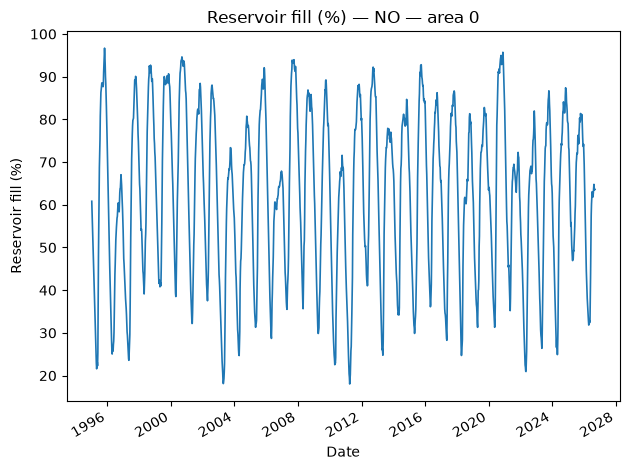

In [31]:
# Show the proportion of reservoir capacity filled, expressed as a percentage.
plot_measurement("fill_fraction")

Reservior fill fluctuates between around 20-95%. Could be seasonal.

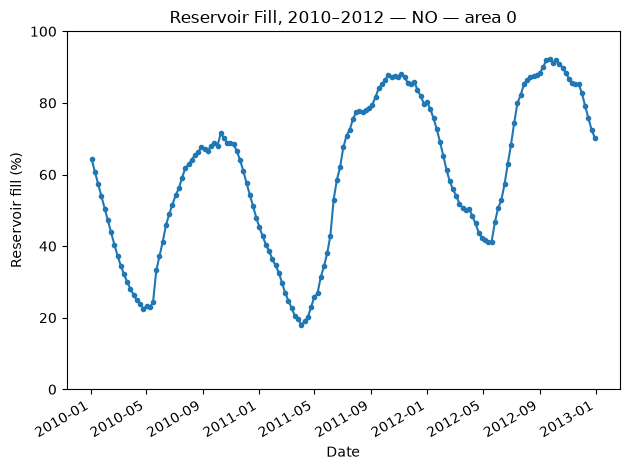

In [35]:
# Select three complete calendar years for the previously selected area.
start_year = 2010
end_year = start_year + 2

three_years = area_df.loc[
    area_df["date"].ge(f"{start_year}-01-01")
    & area_df["date"].lt(f"{end_year + 1}-01-01")
].sort_values("date")

if three_years.empty:
    raise ValueError("No observations are available for the selected years.")

# Convert fill fractions to percentages for display.
fig, ax = plt.subplots()
ax.plot(
    three_years["date"],
    three_years["fill_fraction"] * 100,
    marker=".",
    linewidth=1.5,
)

ax.set_title(f"Reservoir Fill, {start_year}–{end_year} — {area_label}")
ax.set_xlabel("Date")
ax.set_ylabel("Reservoir fill (%)")
ax.set_ylim(0, 100)

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

By investigating a three year span, the reservoir fill is clearly seasonal with highs during the autumn and lows late spring. There is also a trend in this perticular window going upwards, although looking at the entire plot above it does not seem like a "global" trend for the enitre dataset.

### 5.2 Reservoir capacity

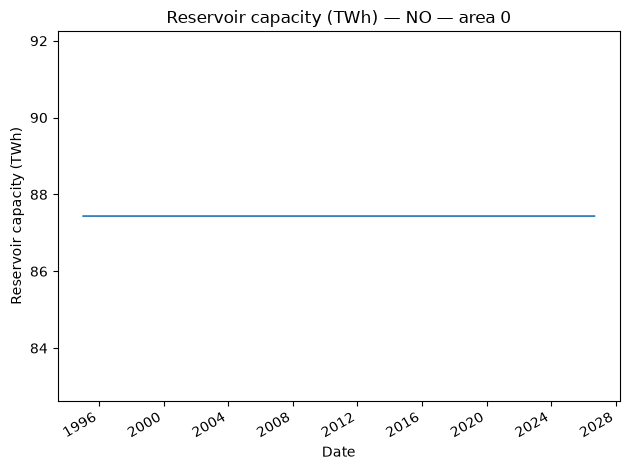

In [30]:
# Show the reported storage capacity in TWh.
plot_measurement("capacity_twh")

For this perticular area, the capacity is constant at just below 88 TWh.

### 5.3 Stored energy

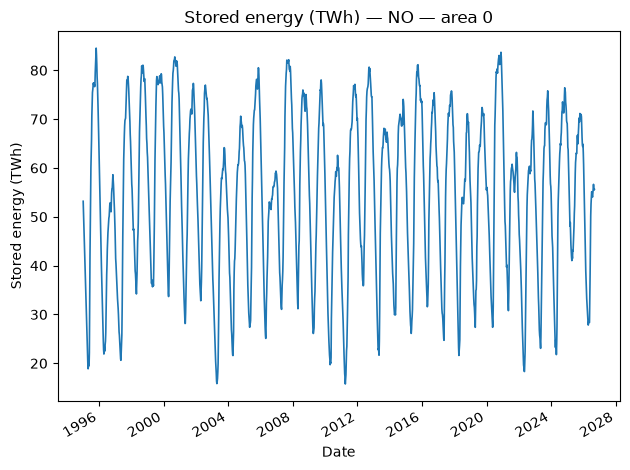

In [34]:
# Show the amount of energy stored in the reservoirs.
plot_measurement("stored_energy_twh")

Looks very similar to the fill plot. Probably also seasonal, but I will not assume.

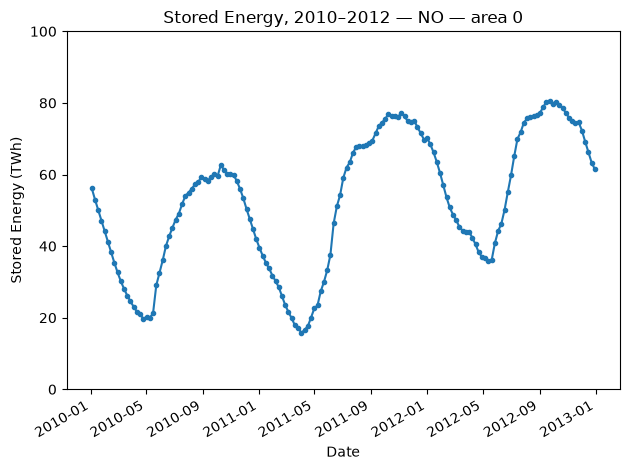

In [39]:
# Select three complete calendar years for the previously selected area.
start_year = 2010
end_year = start_year + 2

three_years_se = area_df.loc[
    area_df["date"].ge(f"{start_year}-01-01")
    & area_df["date"].lt(f"{end_year + 1}-01-01")
].sort_values("date")

if three_years_se.empty:
    raise ValueError("No observations are available for the selected years.")

fig, ax = plt.subplots()
ax.plot(
    three_years_se["date"],
    three_years_se["stored_energy_twh"],
    marker=".",
    linewidth=1.5,
)

ax.set_title(f"Stored Energy, {start_year}–{end_year} — {area_label}")
ax.set_xlabel("Date")
ax.set_ylabel("Stored Energy (TWh)")
ax.set_ylim(0, 100)

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

Also seasonal, with the exact same patterns as the fill plot.

### 5.4 Previous Weeks Fill Percentage

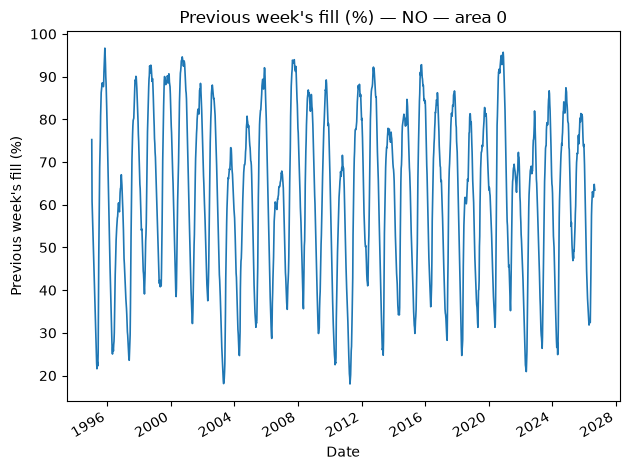

In [40]:
# Plot the reported previous-week value against the current observation date.
plot_measurement("previous_week_fill_fraction")

Also very similar to the fill %. Given that it is the previous weeks fill, it is within reason to assume that it is seasonal, like the other fill column.

### 5.5 Fill fraction change

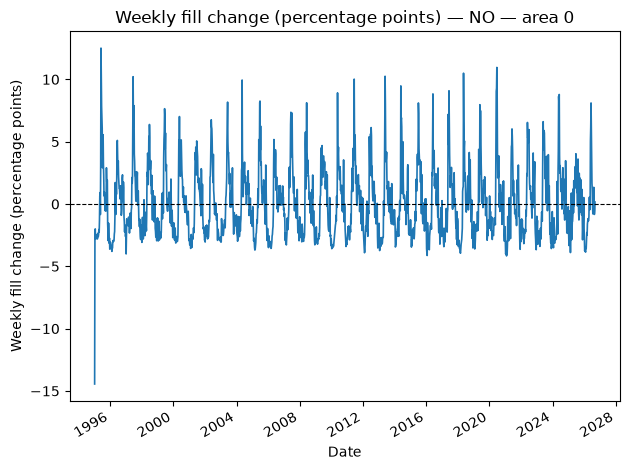

In [41]:
# Positive values indicate increasing fill; negative values indicate decreasing fill.
plot_measurement("fill_fraction_change")

Seems like there is one clear outlier as the very first observation. Other than that it is seasonal with varying peaks, but similar valleys every year. 

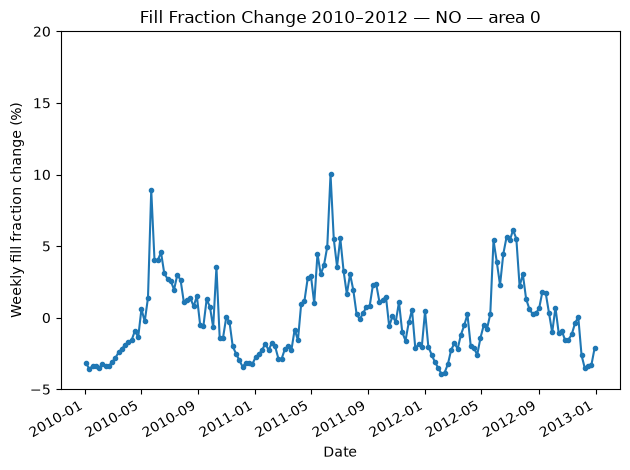

In [45]:
# Select three complete calendar years for the previously selected area.
start_year = 2010
end_year = start_year + 2

three_years_ch = area_df.loc[
    area_df["date"].ge(f"{start_year}-01-01")
    & area_df["date"].lt(f"{end_year + 1}-01-01")
].sort_values("date")

if three_years_ch.empty:
    raise ValueError("No observations are available for the selected years.")

fig, ax = plt.subplots()
ax.plot(
    three_years_ch["date"],
    three_years_ch["fill_fraction_change"] * 100,
    marker=".",
    linewidth=1.5,
)

ax.set_title(f"Fill Fraction Change {start_year}–{end_year} — {area_label}")
ax.set_xlabel("Date")
ax.set_ylabel("Weekly fill fraction change (%)")
ax.set_ylim(-5, 20)

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

A further look into the fill fraction change shows clear seasonality with peaks during the summer and lows during the winter.

### 5.6 Metadata

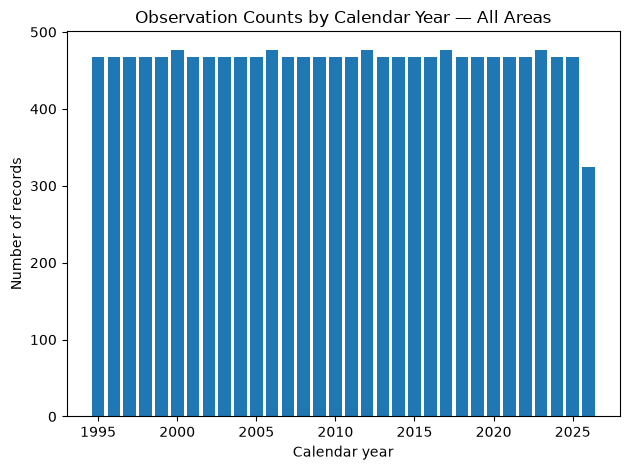

In [46]:
# Observation date: count records per calendar year across the full dataset.
# Partial first or last years can have fewer observations.
observations_per_year = (
    df.groupby(df["date"].dt.year)
    .size()
    .sort_index()
)

fig, ax = plt.subplots()
ax.bar(observations_per_year.index, observations_per_year.values)
ax.set_title("Observation Counts by Calendar Year — All Areas")
ax.set_xlabel("Calendar year")
ax.set_ylabel("Number of records")
fig.tight_layout()
plt.show()

Most years have 52 weeks, although some have 53. Since the data is weekly this explain the slight differences in observations year by year.

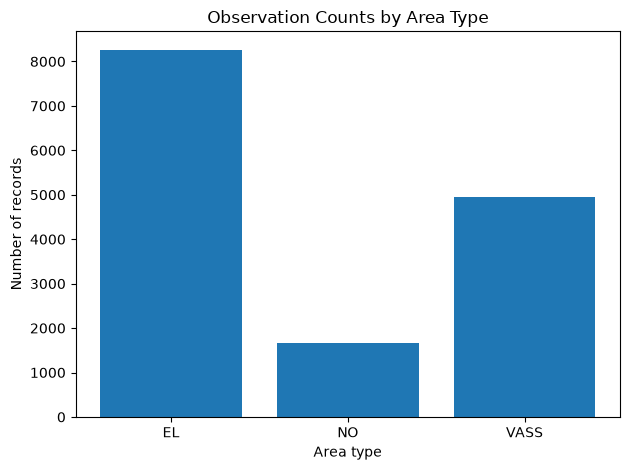

In [47]:
# Area type is categorical, so display record counts rather than a numeric line.
area_type_counts = df["area_type"].value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(area_type_counts.index, area_type_counts.values)
ax.set_title("Observation Counts by Area Type")
ax.set_xlabel("Area type")
ax.set_ylabel("Number of records")
fig.tight_layout()
plt.show()

EL has significantly more observations than the others, with VASS second and NO with the least observations.

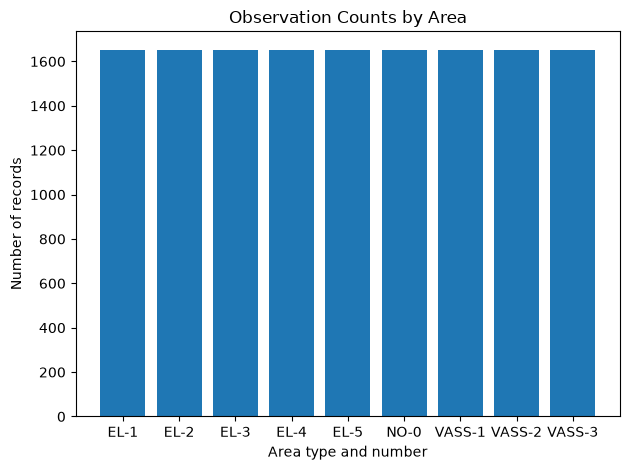

In [48]:
# Area numbers are meaningful only together with their area types.
area_counts = (
    df.groupby(["area_type", "area_number"])
    .size()
    .sort_index()
)

area_labels = [
    f"{area_type}-{area_number}"
    for area_type, area_number in area_counts.index
]

fig, ax = plt.subplots()
ax.bar(area_labels, area_counts.values)
ax.set_title("Observation Counts by Area")
ax.set_xlabel("Area type and number")
ax.set_ylabel("Number of records")
fig.tight_layout()
plt.show()

All of the area type and numbers have the same number of observations.

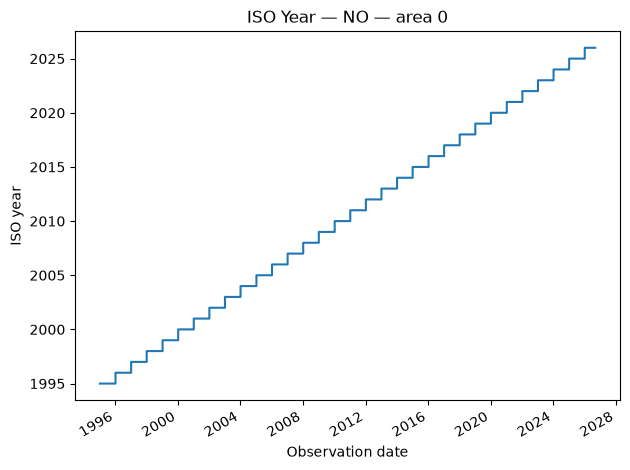

In [49]:
# Show the recorded ISO year over time for the selected area.
# ISO week-years can differ from calendar years around New Year.
fig, ax = plt.subplots()
ax.step(area_df["date"], area_df["iso_year"], where="post")
ax.set_title(f"ISO Year — {area_label}")
ax.set_xlabel("Observation date")
ax.set_ylabel("ISO year")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

ISO year and observation year seems to coincide.

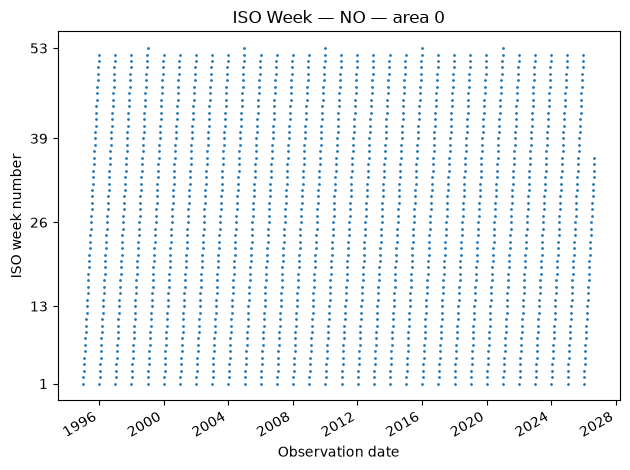

In [50]:
# ISO week resets at the start of each ISO year.
fig, ax = plt.subplots()
ax.plot(
    area_df["date"],
    area_df["iso_week"],
    linestyle="none",
    marker=".",
    markersize=2,
)
ax.set_title(f"ISO Week — {area_label}")
ax.set_xlabel("Observation date")
ax.set_ylabel("ISO week number")
ax.set_yticks([1, 13, 26, 39, 53])
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

Week number resets every year, with some years containing 53 weeks as mentioned earlier.

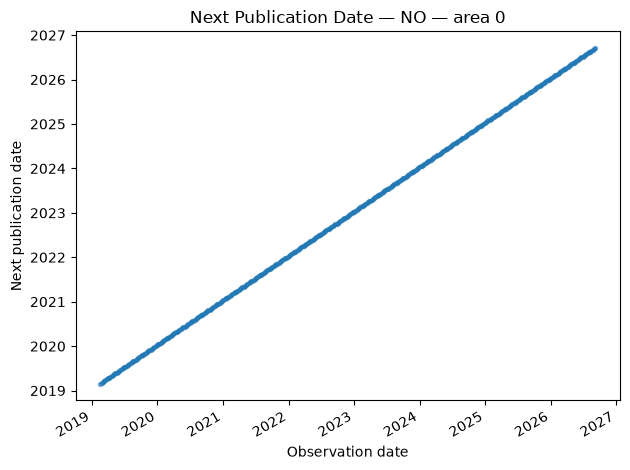

Observations without a publication date: 1258


In [51]:
# Plot only available publication dates; keep placeholders excluded.
publication_df = area_df.dropna(subset=["next_publication_date"])

if publication_df.empty:
    print("No valid publication dates are available for the selected area.")
else:
    fig, ax = plt.subplots()
    ax.scatter(
        publication_df["date"],
        publication_df["next_publication_date"],
        s=8,
        alpha=0.6,
    )

    ax.set_title(f"Next Publication Date — {area_label}")
    ax.set_xlabel("Observation date")
    ax.set_ylabel("Next publication date")

    # Format both axes as dates.
    ax.xaxis_date()
    ax.yaxis_date()

    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

print(
    "Observations without a publication date:",
    area_df["next_publication_date"].isna().sum(),
)

Next publication date seems to be in the near feature of the observation date.

## 6. Comparing Measurements with Different Scales


### 6.1 Why Scaling Is Necessary

Given that the measurements for the columns differ, they need to be scaled in order to plot them together. A standardisation scales the values relative to the individual column mean and standard deviations, giving them the same scale while preserving the distributions.

### 6.2 Standardisation

In [54]:
# Select the reservoir measurements, keeping dates as the index.
measurements = (
    area_df.set_index("date")[measurement_columns]
    .sort_index()
)

# Calculate each measurement's mean and sample standard deviation.
means = measurements.mean()
standard_deviations = measurements.std(ddof=1)

# Identify constant columns directly to avoid floating-point rounding issues.
constant_mask = measurements.nunique(dropna=True).eq(1)

# Undefined or zero standard deviations cannot be used as divisors.
safe_std = standard_deviations.mask(
    constant_mask | standard_deviations.eq(0)
)

standardised_df = (measurements - means) / safe_std

# Constant columns have no defined z-score.
# Display their observed values at zero by convention; preserve missing values.
for column in measurements.columns[constant_mask]:
    standardised_df[column] = measurements[column].where(
        measurements[column].isna(),
        0.0,
    )

# Document the parameters and treatment used for each measurement.
scaling_summary = pd.DataFrame({
    "mean_original_units": means,
    "std_original_units": standard_deviations,
    "constant": constant_mask,
    "treatment": [
        "Displayed at zero (constant)"
        if constant_mask[column]
        else (
            "Not plotted (insufficient data)"
            if pd.isna(safe_std[column])
            else "Standardised"
        )
        for column in measurements.columns
    ],
})

### 6.3 Combined plot

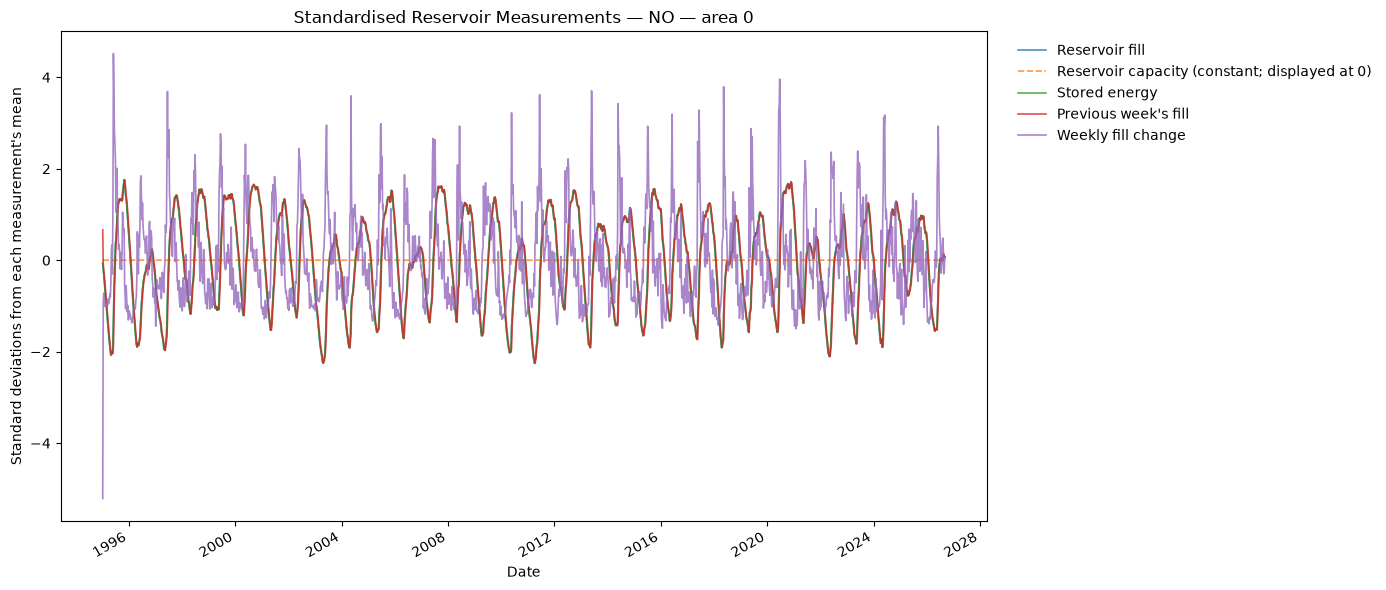

In [53]:
# Labels omit original units because the plotted values are standardised.
series_labels = {
    "fill_fraction": "Reservoir fill",
    "capacity_twh": "Reservoir capacity",
    "stored_energy_twh": "Stored energy",
    "previous_week_fill_fraction": "Previous week's fill",
    "fill_fraction_change": "Weekly fill change",
}

fig, ax = plt.subplots(figsize=(14, 6))

for column in measurement_columns:
    # Skip columns without any values that can be displayed.
    if standardised_df[column].notna().sum() == 0:
        continue

    is_constant = constant_mask[column]
    label = series_labels[column]

    if is_constant:
        label += " (constant; displayed at 0)"

    ax.plot(
        standardised_df.index,
        standardised_df[column],
        label=label,
        linestyle="--" if is_constant else "-",
        linewidth=1.2,
        alpha=0.8,
    )

ax.set_title(f"Standardised Reservoir Measurements — {area_label}")
ax.set_xlabel("Date")
ax.set_ylabel("Standard deviations from each measurement's mean")

# Position the legend outside the plotting area to avoid obscuring the lines.
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

The combined plot shows that Weekly fill change is the most fluctuating column, bit quite a lot of outliers relative to its mean. The capacity is set constant at 0. The three others are very similar, all clustered together into the dark red line.

## 7. Work Log

The goal of this assignment was to explore the reservoirs dataset in a Jupyter Notebook and present the data through interactive plots in Streamlit. I worked step by step, starting with the folder structure and a minimal working app. I then explored the data and added the app’s components gradually. I committed and pushed changes to GitHub after each step to keep track of my progress and maintain a clear project structure.

In the notebook, I loaded the data using Pandas and started with basic checks, including missing values and summary statistics. I renamed the columns to English and converted the dates to datetime values. Since the dataset included several geographical areas, I selected area type NO and area number 0 for further analysis. I plotted the measurements separately and together, and added short comments describing what I observed. I tried to keep these comments accurate without making them unnecessarily long.

For the Streamlit app, I created an account and connected the project to its GitHub repository. I used separate Python files for the pages, with app.py handling navigation. I also created a shared utility file containing a cached function for loading, filtering, sorting and renaming the data.

The table page showed the first month’s values for the five selected measurements using small line charts. The plotting page included a dropdown menu for choosing one measurement or displaying them all together. For the combined plot, I used standardisation so measurements with different units and scales could share one axis. I also added a slider for selecting a range of months, with the first month selected by default.

During deployment, I encountered a dependency-installation error on Streamlit Cloud. Updating requirements.txt to include the necessary packages appeared to solve the problem. After that, the app worked smoothly and updated after each push to GitHub. Building it gradually made it easier to check each change before moving on.

## 8. AI Usage

AI assisted with coding and error explanations. \
GPT-6 Astra was used

